## Module 2: Lập Bảng Dự Phóng Dòng Tiền (Cash Flow Projection)

Ở Module 1, đã phân tích rủi ro tử vong ($q_x$) và xác suất sinh tồn (${}_t p_x$). Trong Module 2, sẽ chuyển hóa các xác suất đó thành **dòng tiền tài chính**. 

Để thực hiện,cần thiết lập các **Giả định Sản phẩm (Actuarial Assumptions)** cho một khách hàng tiêu chuẩn:
*   **Tuổi tham gia (Issue Age):** 30 tuổi.
*   **Số tiền bảo hiểm (Sum Assured):** 1,000,000,000 VNĐ (Công ty chi trả khi có rủi ro).
*   **Phí bảo hiểm hàng năm (Annual Premium):** 15,000,000 VNĐ (Khách hàng đóng vào đầu mỗi năm khi còn sống).
*   **Lãi suất đầu tư (Interest Rate):** 5%/năm.

In [1]:
import pandas as pd

# PHẦN 1: CHUẨN BỊ LẠI DỮ LIỆU TỬ VONG 
mortality = pd.read_csv("../data/mortality_table.csv")
mortality['px'] = 1 - mortality['qx']
mortality['cumulative_survival'] = mortality['px'].cumprod()

# PHẦN 2: THIẾT LẬP GIẢ ĐỊNH SẢN PHẨM (ASSUMPTIONS)
# Đây là hợp đồng bảo hiểm giả định cho 1 người 30 tuổi

sum_assured = 1000000000  # Số tiền bảo hiểm: 1 tỷ VNĐ (Công ty trả khi khách hàng tử vong)
annual_premium = 15000000 # Phí bảo hiểm: 15 triệu VNĐ/năm (Khách hàng đóng khi còn sống)
interest_rate = 0.05      # Lãi suất đầu tư: 5%/năm (Công ty mang tiền phí đi đầu tư lấy lãi)

print(f"Số tiền bảo hiểm (Sum Assured): {sum_assured:,} VNĐ")
print(f"Phí bảo hiểm hàng năm (Premium): {annual_premium:,} VNĐ")
print(f"Lãi suất (Interest Rate): {interest_rate * 100}%")

Số tiền bảo hiểm (Sum Assured): 1,000,000,000 VNĐ
Phí bảo hiểm hàng năm (Premium): 15,000,000 VNĐ
Lãi suất (Interest Rate): 5.0%


### Tính toán Dòng tiền thuần (Net Cash Flow)

Bước này tính toán dòng tiền kỳ vọng hàng năm dựa trên xác suất sinh tồn và tỷ lệ tử vong. Các công thức được sử dụng bao gồm:

1. **Dòng tiền thu dự kiến (Expected Premium Inflow):**
   Khách hàng đóng phí vào đầu năm với điều kiện họ còn sống.
   $$\text{Expected Premium} = \text{Annual Premium} \times {}_t p_x$$

2. **Dòng tiền chi dự kiến (Expected Death Benefit Outflow):**
   Công ty chi trả bồi thường nếu khách hàng tử vong trong năm đó. Xác suất tử vong trong năm bằng xác suất sống đến đầu năm nhân với tỷ lệ tử vong trong năm.
   $$\text{Expected Benefit} = \text{Sum Assured} \times ({}_t p_x \times q_x)$$

3. **Dòng tiền thuần (Net Cash Flow):**
   Phản ánh dòng tiền vào/ra của hợp đồng trước khi xét đến yếu tố lãi suất đầu tư.
   $$\text{Net Cash Flow} = \text{Expected Premium} - \text{Expected Benefit}$$

In [2]:
# PHẦN 3: TÍNH TOÁN DÒNG TIỀN (CASH FLOW PROJECTION)
df_cf = mortality[['age', 'qx', 'px', 'cumulative_survival']].copy()

# 1. Dòng tiền thu dự kiến (Expected Premium Inflow)
# Giả định: Khách hàng đóng phí vào đầu năm, với điều kiện họ còn sống.
df_cf['premium_inflow'] = annual_premium * df_cf['cumulative_survival']

# 2. Dòng tiền chi dự kiến (Expected Death Benefit Outflow)
# Giả định: Công ty trả bồi thường nếu khách hàng tử vong trong năm đó.
# Xác suất tử vong trong năm = Xác suất sống đến đầu năm * Tỷ lệ tử vong trong năm
df_cf['death_benefit_outflow'] = sum_assured * (df_cf['cumulative_survival'] * df_cf['qx'])

# 3. Dòng tiền thuần (Net Cash Flow)
# Bằng Dòng tiền thu trừ đi Dòng tiền chi
df_cf['net_cash_flow'] = df_cf['premium_inflow'] - df_cf['death_benefit_outflow']

df_cf[['age', 'premium_inflow', 'death_benefit_outflow', 'net_cash_flow']].head()

,age,premium_inflow,death_benefit_outflow,net_cash_flow
0,30,1.498575e+07,9.490975e+05,1.403665e+07
1,31,1.497076e+07,9.980509e+05,1.397271e+07
2,32,1.495504e+07,1.046853e+06,1.390819e+07
3,33,1.493859e+07,1.095497e+06,1.384310e+07
4,34,1.492142e+07,1.143975e+06,1.377744e+07


### Hiện giá Dòng tiền (Present Value of Cash Flows)

Để đưa các dòng tiền trong tương lai về giá trị hiện tại, cần sử dụng hệ số chiết khấu $v$:
$$v = \frac{1}{1 + i}$$

Các giả định tính toán (Time value of money):
1. **Thời gian ($t$):** Bắt đầu từ năm 0 (tuổi 30).
2. **PV Premium:** Thu vào đầu năm $t$. Chiết khấu bằng $v^t$.
3. **PV Death Benefit:** Trả vào cuối năm $t$. Chiết khấu bằng $v^{t+1}$.
4. **NPV Cash Flow:** Bằng PV Premium trừ đi PV Death Benefit.

In [3]:

pd.set_option('display.float_format', lambda x: '%.0f' % x)

# 1. Khởi tạo hệ số chiết khấu v và thời gian t
v = 1 / (1 + interest_rate)
df_cf['t'] = df_cf['age'] - df_cf['age'].min()

# 2. Tính Hiện giá Dòng tiền thu (PV Premium Inflow)
df_cf['pv_premium'] = df_cf['premium_inflow'] * (v ** df_cf['t'])

# 3. Tính Hiện giá Dòng tiền chi (PV Death Benefit Outflow)
df_cf['pv_death_benefit'] = df_cf['death_benefit_outflow'] * (v ** (df_cf['t'] + 1))

# 4. Tính Hiện giá Dòng tiền thuần (Net Present Value)
df_cf['npv_cash_flow'] = df_cf['pv_premium'] - df_cf['pv_death_benefit']

# In ra 5 dòng đầu
df_cf[['age', 't', 'pv_premium', 'pv_death_benefit', 'npv_cash_flow']].head()

,age,t,pv_premium,pv_death_benefit,npv_cash_flow
0,30,0,14985750,903902,14081848
1,31,1,14257871,905262,13352609
2,32,2,13564667,904311,12660356
3,33,3,12904520,901268,12003251
4,34,4,12275885,896334,11379551


### Tổng kết Dòng tiền và Lợi nhuận (Profitability Analysis)

Bước cuối cùng của dự phóng dòng tiền là tổng hợp các giá trị hiện tại (PV) để đánh giá khả năng sinh lời của sản phẩm.

*   **Total EPV Premium:** Tổng hiện giá phí bảo hiểm kỳ vọng thu được.
*   **Total EPV Benefit:** Tổng hiện giá quyền lợi tử vong kỳ vọng phải trả.
*   **Expected Profit:** Lợi nhuận kỳ vọng (Total EPV Premium - Total EPV Benefit).
*   **Trực quan hóa:** Vẽ biểu đồ cột để so sánh dòng tiền thu và chi qua từng độ tuổi.

Tổng hiện giá Phí thu (EPV Premium): 199,293,273 VNĐ
Tổng hiện giá Bồi thường (EPV Benefit): 21,972,142 VNĐ
Lợi nhuận kỳ vọng (Expected Profit): 177,321,132 VNĐ
Biên lợi nhuận (Profit Margin): 88.97%



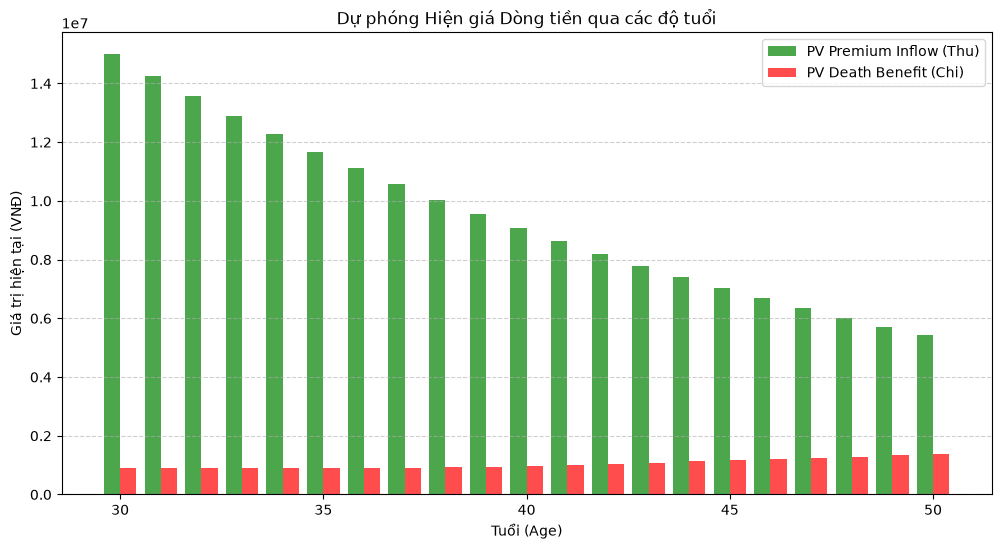

In [4]:
import matplotlib.pyplot as plt

# 1. Tính tổng các dòng tiền (Total Expected Present Value)
total_epv_premium = df_cf['pv_premium'].sum()
total_epv_benefit = df_cf['pv_death_benefit'].sum()
expected_profit = total_epv_premium - total_epv_benefit
profit_margin = expected_profit / total_epv_premium

print(f"Tổng hiện giá Phí thu (EPV Premium): {total_epv_premium:,.0f} VNĐ")
print(f"Tổng hiện giá Bồi thường (EPV Benefit): {total_epv_benefit:,.0f} VNĐ")
print(f"Lợi nhuận kỳ vọng (Expected Profit): {expected_profit:,.0f} VNĐ")
print(f"Biên lợi nhuận (Profit Margin): {profit_margin * 100:.2f}%\n")

# 2. Vẽ biểu đồ trực quan hóa Dòng tiền (Bar Chart)
plt.figure(figsize=(12, 6))

# Vẽ cột thu (màu xanh lá) và cột chi (màu đỏ) 
plt.bar(df_cf['age'] - 0.2, df_cf['pv_premium'], width=0.4, label='PV Premium Inflow (Thu)', color='green', alpha=0.7)
plt.bar(df_cf['age'] + 0.2, df_cf['pv_death_benefit'], width=0.4, label='PV Death Benefit (Chi)', color='red', alpha=0.7)

plt.title('Dự phóng Hiện giá Dòng tiền qua các độ tuổi')
plt.xlabel('Tuổi (Age)')
plt.ylabel('Giá trị hiện tại (VNĐ)')
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.6)

plt.savefig('../outputs/cashflow_projection.png')
plt.show()

### Phân tích và Nhận xét Dòng tiền (Cash Flow Analysis)

Dựa trên biểu đồ Hiện giá Dòng tiền, ta rút ra các kết luận Actuarial sau:

*   **Xu hướng Dòng tiền thu (PV Premium):** Cột màu xanh giảm dần theo thời gian. Sự suy giảm này là kết quả của tác động kép từ hệ số chiết khấu dòng tiền ($v^t$) và sự sụt giảm của xác suất sống sót (${}_t p_x$) qua từng năm.
*   **Xu hướng Dòng tiền chi (PV Death Benefit):** Cột màu đỏ có xu hướng tăng dần. Mặc dù dòng tiền tương lai bị chiết khấu, tốc độ gia tăng rủi ro tử vong ($q_x$) theo độ tuổi lớn hơn tác động của lãi suất, dẫn đến kỳ vọng chi trả cao hơn ở những năm sau.
*   **Đánh giá Sinh lời (Profitability):** Tổng hiện giá phí thu đạt 199.29 triệu VNĐ, vượt xa tổng hiện giá bồi thường là 21.97 triệu VNĐ. Biên lợi nhuận kỳ vọng đạt **88.97%**, cho thấy sản phẩm có rủi ro thấp và khả năng sinh lời cao với tệp khách hàng này.